Found 26 classes. Generating visualization...


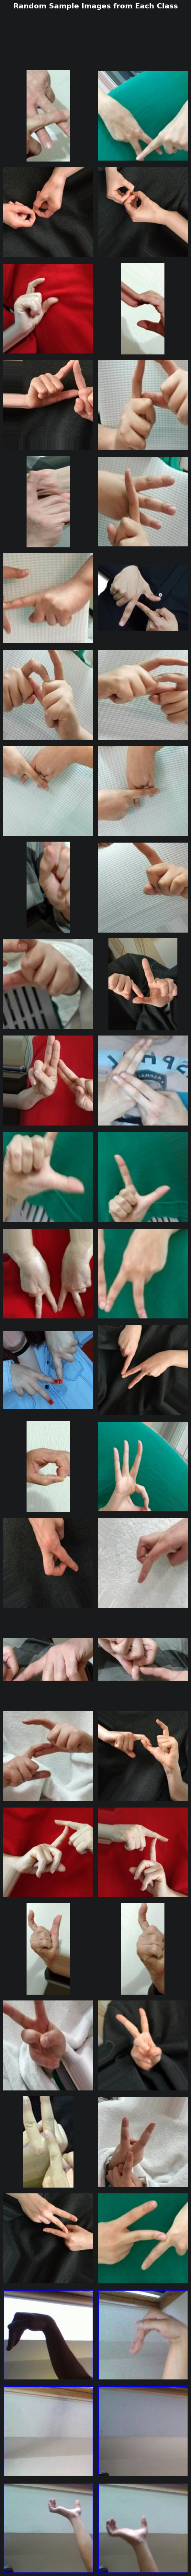

Visualization completed successfully.


In [1]:
# Imports
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# --- 1. Visualize Random Samples from the Dataset ---
dataset_path = "../dataset"
num_samples_per_class = 2  # Number of sample images to show per class

if os.path.exists(dataset_path):
    class_dirs = [d for d in sorted(os.listdir(dataset_path)) if os.path.isdir(os.path.join(dataset_path, d))]

    if not class_dirs:
        print("No class directories found in the dataset path.")
    else:
        print(f"Found {len(class_dirs)} classes. Generating visualization...")

        # Determine grid size
        fig, axes = plt.subplots(len(class_dirs), num_samples_per_class, figsize=(num_samples_per_class * 3, len(class_dirs) * 3))

        # Handle single class edge case for matplotlib axes indexing
        if len(class_dirs) == 1:
            axes = np.expand_dims(axes, axis=0)

        for i, class_name in enumerate(class_dirs):
            class_dir = os.path.join(dataset_path, class_name)
            image_files = [f for f in os.listdir(class_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

            # Select random samples
            selected_files = random.sample(image_files, min(len(image_files), num_samples_per_class))

            for j in range(num_samples_per_class):
                # Handle axes indexing safely whether 1D or 2D array
                ax = axes[i, j] if len(class_dirs) > 1 else axes[j]

                if j < len(selected_files):
                    img_path = os.path.join(class_dir, selected_files[j])
                    try:
                        img = Image.open(img_path)
                        ax.imshow(img)
                        ax.axis("off")
                        if j == 0:
                            ax.set_ylabel(class_name, fontsize=12, fontweight='bold', rotation=0, labelpad=30, va='center')
                    except Exception as e:
                        ax.text(0.5, 0.5, "Error Loading", ha='center', va='center')
                        ax.axis("off")
                else:
                    ax.axis("off")

        plt.suptitle("Random Sample Images from Each Class", fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        print("Visualization completed successfully.")
else:
    print(f"Error: {dataset_path} does not exist")